<a href="https://colab.research.google.com/github/emanuelsandez/challenge3-DS-LATAM/blob/main/TelecomX2_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Desafío TelecomX - 2

##**Preparación de los datos**

###Carga de data del desafío anterior

In [51]:
import pandas as pd

In [52]:
datos = pd.read_csv('/content/datos_tratados.csv')
datos.shape

(7032, 22)

###Eliminación de data irrelevante

In [53]:
#Estructura de los datos
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerID         7032 non-null   object 
 1   Churn              7032 non-null   int64  
 2   gender             7032 non-null   object 
 3   senior_citizen     7032 non-null   int64  
 4   partner            7032 non-null   int64  
 5   dependents         7032 non-null   int64  
 6   tenure             7032 non-null   int64  
 7   phone_service      7032 non-null   int64  
 8   multiple_lines     7032 non-null   int64  
 9   internet_service   7032 non-null   object 
 10  online_security    7032 non-null   int64  
 11  online_backup      7032 non-null   int64  
 12  device_protection  7032 non-null   int64  
 13  tech_support       7032 non-null   int64  
 14  streaming_tv       7032 non-null   int64  
 15  streaming_movies   7032 non-null   int64  
 16  contract           7032 

In [54]:
datos.describe()

,Churn,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,paperless_billing,monthly_charges,total_charges,cuentas_diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.162400,0.482509,0.298493,32.421786,0.903299,0.421928,0.286547,0.344852,0.343857,0.290102,0.384386,0.388367,0.592719,64.798208,2283.300441,2.159891
std,0.441782,0.368844,0.499729,0.457629,24.545260,0.295571,0.493902,0.452180,0.475354,0.475028,0.453842,0.486484,0.487414,0.491363,30.085974,2266.771362,1.002955
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.587500,401.450000,1.187500
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,1397.475000,2.340000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.862500,3794.737500,2.992500
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


In [55]:
#Eliminar columnas que no relevantes en el análisis
datos = datos.drop(['customerID', 'cuentas_diarias'], axis=1)

In [56]:
#Variables categóricas
datos.describe(include='O')

,gender,internet_service,contract,payment_method
count,7032,7032,7032,7032
unique,2,3,3,4
top,Male,Fiber optic,Month-to-month,Electronic check
freq,3549,3096,3875,2365


In [57]:
#Importar bibliotecas para graficar
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='total_charges', ylabel='Count'>

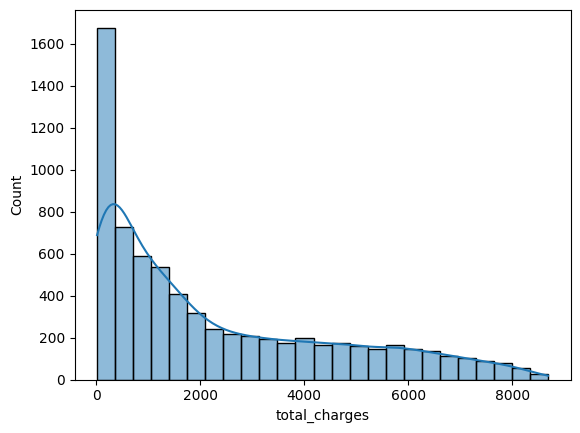

In [58]:
sns.histplot(data=datos,x='total_charges',kde=True)

###Encoding de variables categóricas

In [59]:
#Reemplazar datos con 2 opciones
datos['gender'] = datos['gender'].replace({'Female': 0, 'Male': 1})

/tmp/ipykernel_286/1719362470.py:2: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [60]:
#Codificando variables con más de 2 opciones
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

columnas = datos.columns

one_hot = make_column_transformer((OneHotEncoder(drop='if_binary'),
                                   ['internet_service','contract','payment_method']),
                                  remainder='passthrough', sparse_threshold=0,
                                  force_int_remainder_cols=False)

datos_codificados = one_hot.fit_transform(datos)

In [61]:
#Obtener nombres de las columnas
one_hot.get_feature_names_out(columnas)

array(['onehotencoder__internet_service_DSL',
       'onehotencoder__internet_service_Fiber optic',
       'onehotencoder__internet_service_No',
       'onehotencoder__contract_Month-to-month',
       'onehotencoder__contract_One year',
       'onehotencoder__contract_Two year',
       'onehotencoder__payment_method_Bank transfer automatic',
       'onehotencoder__payment_method_Credit card automatic',
       'onehotencoder__payment_method_Electronic check',
       'onehotencoder__payment_method_Mailed check', 'remainder__Churn',
       'remainder__gender', 'remainder__senior_citizen',
       'remainder__partner', 'remainder__dependents', 'remainder__tenure',
       'remainder__phone_service', 'remainder__multiple_lines',
       'remainder__online_security', 'remainder__online_backup',
       'remainder__device_protection', 'remainder__tech_support',
       'remainder__streaming_tv', 'remainder__streaming_movies',
       'remainder__paperless_billing', 'remainder__monthly_charges',
   

In [62]:
#Almacenar datos
df_datos_cod = pd.DataFrame(datos_codificados, columns=one_hot.get_feature_names_out(columnas))
df_datos_cod

,onehotencoder__internet_service_DSL,onehotencoder__internet_service_Fiber optic,onehotencoder__internet_service_No,onehotencoder__contract_Month-to-month,onehotencoder__contract_One year,onehotencoder__contract_Two year,onehotencoder__payment_method_Bank transfer automatic,onehotencoder__payment_method_Credit card automatic,onehotencoder__payment_method_Electronic check,onehotencoder__payment_method_Mailed check,...,remainder__multiple_lines,remainder__online_security,remainder__online_backup,remainder__device_protection,remainder__tech_support,remainder__streaming_tv,remainder__streaming_movies,remainder__paperless_billing,remainder__monthly_charges,remainder__total_charges
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,65.60,593.30
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,59.90,542.40
2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,73.90,280.85
3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,98.00,1237.85
4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,55.15,742.90
7028,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,85.10,1873.70
7029,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,50.30,92.75
7030,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,67.85,4627.65


###Verificar proporción de Evasión

In [63]:
df_datos_cod['remainder__Churn'].value_counts(normalize=True)

,proportion
remainder__Churn,
0.0,0.734215
1.0,0.265785


###Balanceo de la data con SMOTE

In [64]:
#Split de de variables
X = df_datos_cod.drop(['remainder__Churn'], axis=1)
y = df_datos_cod['remainder__Churn']

In [65]:
from imblearn.over_sampling import SMOTE

oversampling = SMOTE()
X_balanceada, y_balanceada = oversampling.fit_resample(X, y)

y_balanceada.value_counts(normalize=True)

,proportion
remainder__Churn,
0.0,0.5
1.0,0.5


###Normalizando datos

In [66]:
#Se normaliza el eje 'x', dado que el eje 'y' está en valores de 0 a 1
from sklearn.preprocessing import MinMaxScaler

normalizacion = MinMaxScaler()
X_normalizado = normalizacion.fit_transform(X_balanceada)

pd.DataFrame(X_normalizado)

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1.0,0.0,0.0,0.0,1.0,0.0,0.000000,0.0,0.000000,1.000000,...,0.000000,0.0,1.000000,0.000000,1.0,1.000000,0.000000,1.000000,0.471144,0.066294
1,1.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.0,0.000000,1.000000,...,1.000000,0.0,0.000000,0.000000,0.0,0.000000,1.000000,0.000000,0.414428,0.060420
2,0.0,1.0,0.0,1.0,0.0,0.0,0.000000,0.0,1.000000,0.000000,...,0.000000,0.0,0.000000,1.000000,0.0,0.000000,0.000000,1.000000,0.553731,0.030239
3,0.0,1.0,0.0,1.0,0.0,0.0,0.000000,0.0,1.000000,0.000000,...,0.000000,0.0,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,0.793532,0.140670
4,0.0,1.0,0.0,1.0,0.0,0.0,0.000000,0.0,0.000000,1.000000,...,0.000000,0.0,0.000000,0.000000,1.0,1.000000,0.000000,1.000000,0.653234,0.028687
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10321,0.0,1.0,0.0,1.0,0.0,0.0,0.000000,0.0,0.252249,0.747751,...,0.747751,0.0,0.252249,0.000000,0.0,0.000000,0.000000,0.747751,0.558227,0.091615
10322,0.0,1.0,0.0,1.0,0.0,0.0,0.000000,0.0,1.000000,0.000000,...,0.136133,0.0,0.000000,0.000000,0.0,0.863867,0.000000,0.136133,0.600328,0.028675
10323,0.0,1.0,0.0,1.0,0.0,0.0,0.176096,0.0,0.000000,0.823904,...,0.000000,0.0,0.176096,0.823904,0.0,0.176096,0.823904,1.000000,0.677784,0.018554
10324,0.0,1.0,0.0,0.0,1.0,0.0,0.000000,0.0,1.000000,0.000000,...,1.000000,0.0,0.346636,1.000000,1.0,1.000000,1.000000,1.000000,0.903733,0.521053


##Correlación y Selección de variables

###Análisis de correlación

In [67]:
correlacion = df_datos_cod.corr()

In [68]:
#Correlación de todas las variables respecto a la variable Churn
correlacion['remainder__Churn'].abs().sort_values(ascending=False)

,remainder__Churn
remainder__Churn,1.000000
onehotencoder__contract_Month-to-month,0.404565
remainder__tenure,0.354049
onehotencoder__internet_service_Fiber optic,0.307463
onehotencoder__contract_Two year,0.301552
onehotencoder__payment_method_Electronic check,0.301455
onehotencoder__internet_service_No,0.227578
remainder__total_charges,0.199484
remainder__monthly_charges,0.192858
remainder__paperless_billing,0.191454


In [69]:
#Correlación de las variables numéricas con respecto a la variable Churn
variables_numericas = ['remainder__tenure', 'remainder__monthly_charges', 'remainder__total_charges']

corr_numericas = df_datos_cod[variables_numericas + ['remainder__Churn']].corr()
corr_numericas['remainder__Churn'].sort_values(ascending=False)

,remainder__Churn
remainder__Churn,1.000000
remainder__monthly_charges,0.192858
remainder__total_charges,-0.199484
remainder__tenure,-0.354049


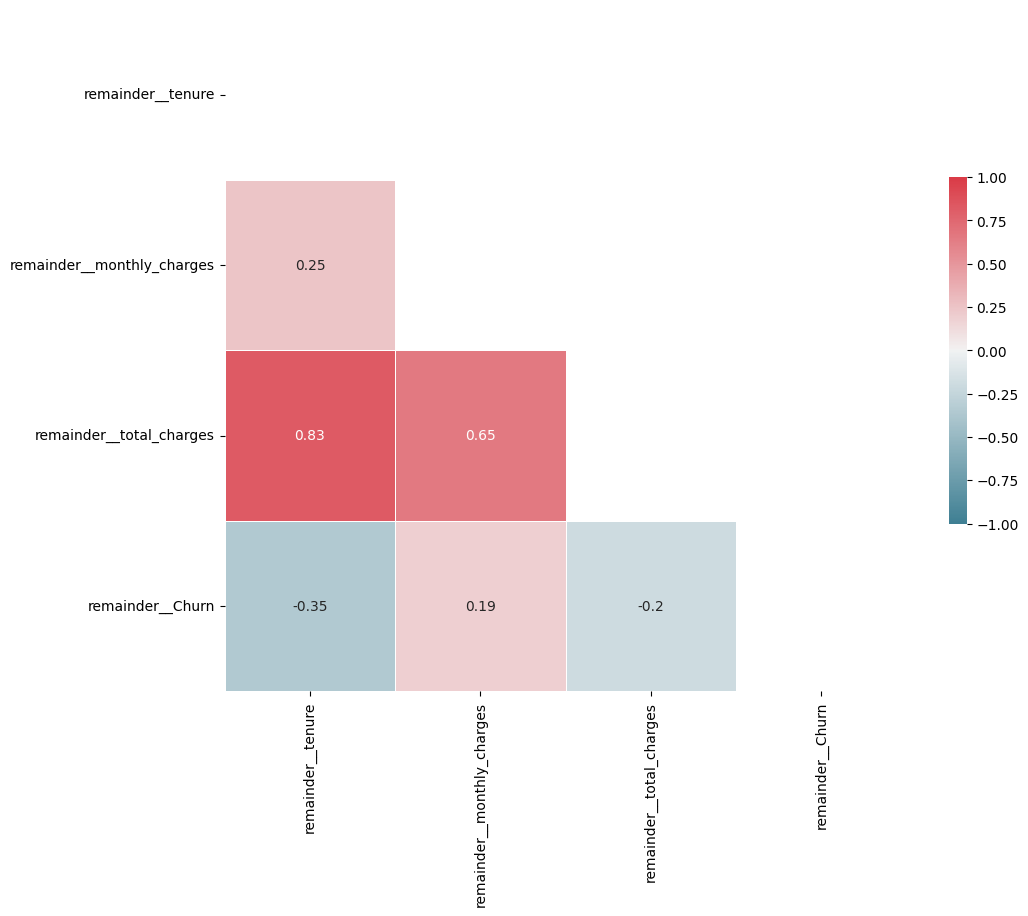

In [70]:
#Correlación de la variable Churn con las variables numéricas
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

mascara = np.zeros_like(corr_numericas, dtype=bool)
mascara[np.triu_indices_from(mascara)] = True

fig, ax = plt.subplots(figsize=(11, 9))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr_numericas, mask=mascara, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, annot=True, cbar_kws={"shrink": .5})
plt.show()

Se aprecia una fuerte correlación positiva entre el tiempo de permanencia y los cargos totales, también entre los cargos totales y los cargos mensuales.

 Si nos enfocamos en el primer caso, resulta evidente que mientras más tiempo permanezca un cliente en Telecom, más dinero ha desembolsado en ese período de permanencia. Esta información se tendría que evaluar, si es que realmente  es un factor relevante para el análisis e incluso se podría considerar retirar esta variable del estudio.

###Análisis enfocado

In [71]:
import plotly.express as px

In [72]:
#Boxplot de Tiempo de contrato vs Cancelación

fig = px.box(df_datos_cod, x='remainder__tenure', color='remainder__Churn')

fig.update_layout(
    width=1050,
    height=600,
    title_text="Tiempo de Contrato según Estado de Cancelación",
    title_x=0.5,
    xaxis_title="Período de Contrato (meses)",
    yaxis_title="Cancelación",
    legend_title="Cancelación"
)

new_names = {'0.0': 'Permanece', '1.0': 'Cancela'}
fig.for_each_trace(lambda t: t.update(name = new_names[t.name]))

fig.show()

**Observación:** De la grafica anterior se obtiene que clientes que permanecen en la compañía poseen una mediana de 38 meses y  el 75% de aquellos clientes que se van, tienen una permanencia hasta los 29 meses.

In [73]:
#Boxplot de Gasto Total v/s Cancelación
fig = px.box(df_datos_cod, x='remainder__total_charges', color='remainder__Churn')

fig.update_layout(
    width=1050,
    height=600,
    title_text="Cargos totales Cancelación de Contrato",
    title_font_size=22,
    title_x=0.4,
    xaxis_title="Gasto total",
    yaxis_title="Cancelación",
    legend_title="Cancelación"
)


new_names = {'0.0': 'Permanece', '1.0': 'Cancela'}
fig.for_each_trace(lambda t: t.update(name = new_names[t.name]))

fig.show()

**Observación:** Del gráfico pse deprende que la mediana de gasto de los clientes que permanecen es de 1684 y de los que cancelan es de 704. Este dato podría deberse a la corrleación que existe entre el período de permanencia y la cantidad de gastos totales.

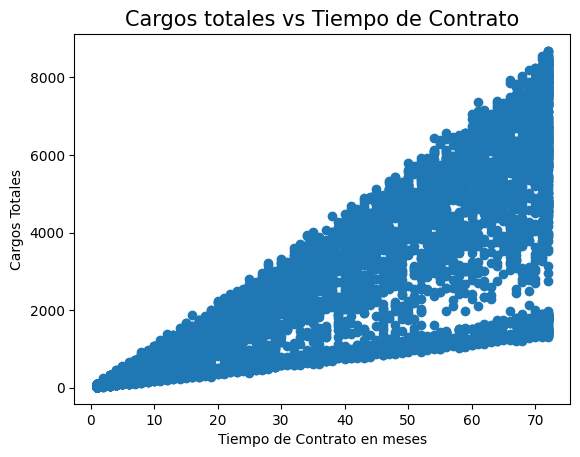

In [74]:
#Grafico Cargos totales versus Tiempo de contrato

plt.scatter(df_datos_cod['remainder__tenure'], df_datos_cod['remainder__total_charges'])
plt.title('Cargos totales vs Tiempo de Contrato', loc ='center', size =15)
plt.xlabel('Tiempo de Contrato en meses')
plt.ylabel('Cargos Totales');

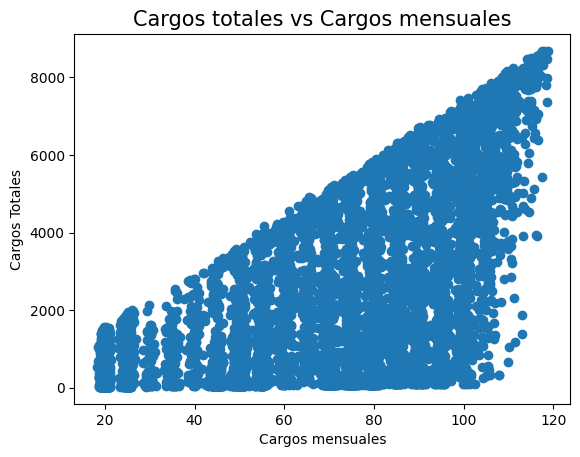

In [75]:
#SGrafico Cargos totales versus Cargos mensuales

plt.scatter(df_datos_cod['remainder__monthly_charges'], df_datos_cod['remainder__total_charges'])
plt.title('Cargos totales vs Cargos mensuales', loc ='center', size =15)
plt.xlabel('Cargos mensuales')
plt.ylabel('Cargos Totales');

##Modelado Predictivo

###Datos para Árbol de Decisiones

Separación de datos

In [76]:
#Quitar variable 'x' de la variable gasto total
X = X_balanceada.drop(['remainder__total_charges'], axis=1)
y = y_balanceada

In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [78]:
#Normalización de 'x'
X_norm = normalizacion.fit_transform(X)
X_train_norm = normalizacion.fit_transform(X_train)
X_test_norm = normalizacion.transform(X_test)

Creación de modelos

In [79]:
#Modelo baseline
from sklearn.dummy import DummyClassifier

modelo_base = DummyClassifier(random_state=42)
modelo_base.fit(X_train, y_train)

DummyClassifier(random_state=42)

In [80]:
#Modelo Random Forest
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(max_depth=5, random_state=42)
modelo_rf.fit(X_train,y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [81]:
X_balanceada['remainder__monthly_charges'].max()

118.75

** Observación:** Se debe utilizar las variables normalizadas para la creación del modelo KNN, dado que se basa en determinar la distancia de la variable respuesta con las variables explicativas. Por ejemplo, la variable balanceada de cargos mensuales que tiene un máximo de 118.75 podría pesar mucho más en el modelo que una variable categórica que tiene un máximo de 1.

In [82]:
#Modelo KNN
from sklearn.neighbors import KNeighborsClassifier

modelo_knn = KNeighborsClassifier()
modelo_knn.fit(X_train_norm,y_train)

KNeighborsClassifier()

###Evaluación de los Modelos

Score para ver la generalización

In [83]:
#Modelo base
print(f'El score de entrenamiento para el modelo base es de: {modelo_base.score(X_train, y_train):.2f}. El score de prueba para el modelo base es de: {modelo_base.score(X_test, y_test):.2f}')

El score de entrenamiento para el modelo base es de: 0.50. El score de prueba para el modelo base es de: 0.50


In [84]:
#Modelo Random Forest
print(f'El score de entrenamiento para el modelo Random Forest es de: {modelo_rf.score(X_train, y_train):.2f}. El score de prueba para el modelo Random Forest es de: {modelo_rf.score(X_test, y_test):.2f}')

El score de entrenamiento para el modelo Random Forest es de: 0.84. El score de prueba para el modelo Random Forest es de: 0.83


In [85]:
#Modelo KNN
print(f'El score de entrenamiento para el modelo KNN es de : {modelo_knn.score(X_train_norm, y_train):.2f}. El score de prueba para el modelo KNN es de: {modelo_knn.score(X_test_norm, y_test):.2f}')

El score de entrenamiento para el modelo KNN es de : 0.85. El score de prueba para el modelo KNN es de: 0.77


####Exactitud, Precisión, Recall, F1-score y Matriz de confusión

In [86]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

In [87]:
metricas = [accuracy_score, precision_score, recall_score, f1_score]
metricas_nombres = ['accuracy', 'precision', 'recall', 'f1']

In [89]:
#Modelo baseline
y_pred_base = modelo_base.predict(X_test)

for metrica, nombre in zip(metricas, metricas_nombres):
  if nombre in ['precision', 'f1']:
    valor_metrica = metrica(y_test, y_pred_base, zero_division=np.nan)
  else:
    valor_metrica = metrica(y_test, y_pred_base)
  print(f'La métrica "{nombre}" para el modelo baseline es: {valor_metrica:.2f}')

La métrica "accuracy" para el modelo baseline es: 0.50
La métrica "precision" para el modelo baseline es: nan
La métrica "recall" para el modelo baseline es: 0.00
La métrica "f1" para el modelo baseline es: 0.00


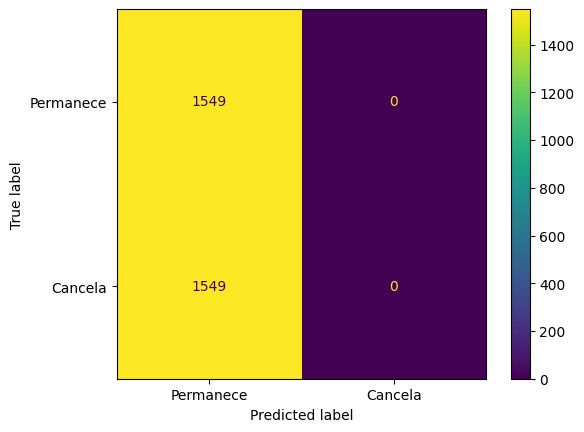

In [90]:
matriz_confusion_base = confusion_matrix(y_test, y_pred_base)
visualizacion_base = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion_base, display_labels=['Permanece','Cancela'])
visualizacion_base.plot()

In [91]:

#Modelo Random Forest
y_pred_rf = modelo_rf.predict(X_test)

for metrica, nombre in zip(metricas, metricas_nombres):
  if nombre in ['precision', 'f1']:
    valor_metrica = metrica(y_test, y_pred_rf, zero_division=np.nan)
  else:
    valor_metrica = metrica(y_test, y_pred_rf)
  print(f'La métrica "{nombre}" para el modelo Random Forest es: {valor_metrica:.2f}')

La métrica "accuracy" para el modelo Random Forest es: 0.83
La métrica "precision" para el modelo Random Forest es: 0.79
La métrica "recall" para el modelo Random Forest es: 0.90
La métrica "f1" para el modelo Random Forest es: 0.84


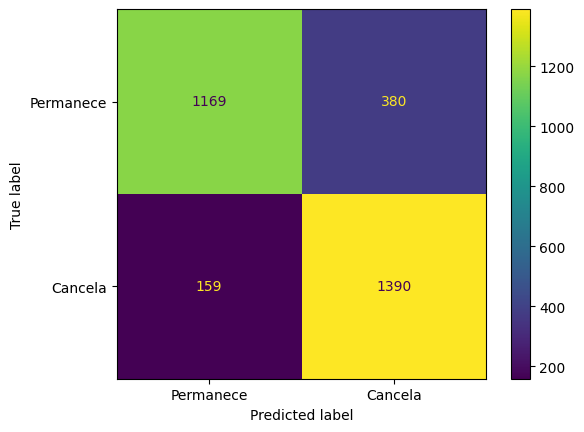

In [92]:
matriz_confusion_rf = confusion_matrix(y_test, y_pred_rf)
visualizacion_rf = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion_rf, display_labels=['Permanece','Cancela'])
visualizacion_rf.plot()

In [93]:
#Modelo KNN
y_pred_knn = modelo_knn.predict(X_test_norm)

for metrica, nombre in zip(metricas, metricas_nombres ):
  if nombre in ['precision', 'f1']:
    valor_metrica = metrica(y_test, y_pred_knn, zero_division=np.nan)
  else:
    valor_metrica = metrica(y_test, y_pred_knn)
  print(f'La métrica "{nombre}" para el modelo KNN es: {valor_metrica:.2f}')

La métrica "accuracy" para el modelo KNN es: 0.77
La métrica "precision" para el modelo KNN es: 0.72
La métrica "recall" para el modelo KNN es: 0.89
La métrica "f1" para el modelo KNN es: 0.80


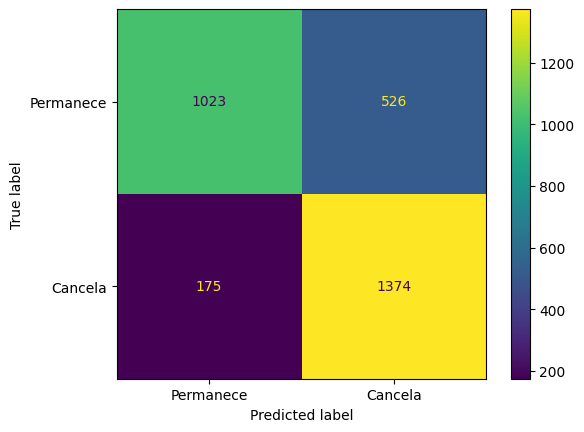

In [94]:
matriz_confusion_knn = confusion_matrix(y_test, y_pred_knn)
visualizacion_knn = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion_knn, display_labels=['Permanece','Cancela'])
visualizacion_knn.plot()

**Observación:** En el modelo Random Forest su score es parecido para los datos de entrenamiento (0.84) y de prueba (0.83). Sin embargo, para el modelo KNN hay una discrepancia un tanto mayor entre los datos de entrenamiento (0.85) y de prueba (0.77), lo que nos podría estar mostrando un sobreajuste a los datos de entrenamiento. Para mitigar esto intentaremos mejorar el modelo aumentando los datos de entrenamiento.

In [95]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_train_norm2 = normalizacion.fit_transform(X_train2)
X_test_norm2 = normalizacion.transform(X_test2)

In [96]:
modelo_knn.fit(X_train_norm2,y_train2)

KNeighborsClassifier()

In [97]:
y_pred_knn2 = modelo_knn.predict(X_test_norm2)

for metrica, nombre in zip(metricas, metricas_nombres):
  if nombre in ['precision', 'f1']:
    valor_metrica = metrica(y_test2, y_pred_knn2, zero_division=np.nan)
  else:
    valor_metrica = metrica(y_test2, y_pred_knn2)
  print(f'La métrica "{nombre}" para el modelo KNN es: {valor_metrica:.2f}')

La métrica "accuracy" para el modelo KNN es: 0.79
La métrica "precision" para el modelo KNN es: 0.73
La métrica "recall" para el modelo KNN es: 0.90
La métrica "f1" para el modelo KNN es: 0.81


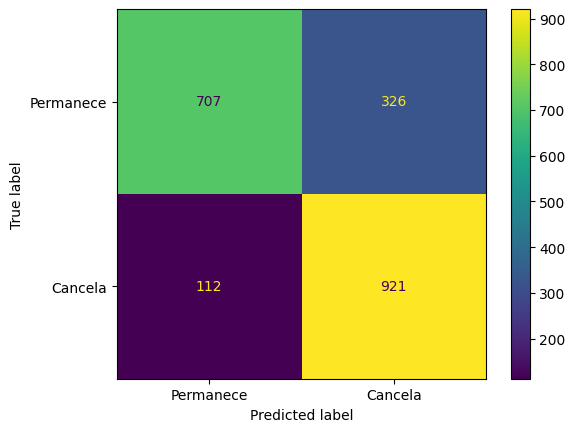

In [ ]:
matriz_confusion_knn = confusion_matrix(y_test2, y_pred_knn2)
visualizacion_knn = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion_knn, display_labels=['Permanece','Cancela'])
visualizacion_knn.plot()

**Observación:**  El parámetro más importante para el este modelo es Recall, ya que estamos intentando evitar la clasificación incorrecta de los clientes que cancelan como si permanecieran con el contrato (Error tipo II), ya que necesitamos clasificar bien a aquellos que abandonan para dirigir nuestros esfuerzos en evitarlo.

Si bien mejoramos un poco el modelo y el Recall Además, al revisar la matriz de confusión podemos observar que disminuyó la predicción de aquellos cancelados correctamente clasificados.

Dado lo anterior, es que seleccionaremos el modelo de Random Forest e intentaremos mejorarlo haciendo ajuste de hiperparámetros.

In [98]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [50,100,150],
              'max_depth' : [3,5,7]}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model_grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid= param_grid, cv=skf, scoring='recall')
model_grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [3, 5, 7],
                         'n_estimators': [50, 100, 150]},
             scoring='recall')

In [99]:
model_grid.best_params_

{'max_depth': 5, 'n_estimators': 50}

**Observación:** Los parámetros obtenidos para el modelo RandomForest son los que ya hemos utilizado, ya que, por defecto n_estimators es 50 y ajustamos el máximo de profundidad en 5, por lo que este es el mejor modelo que tenemos con un Recall de 0.88, la menor diferencia entre score de entrenamiento y prueba, y una mejor cantidad clientes que abandonan clasificados correctamente.

##Interpretación y conclusiones

###Análisis de la importancia de las Variables

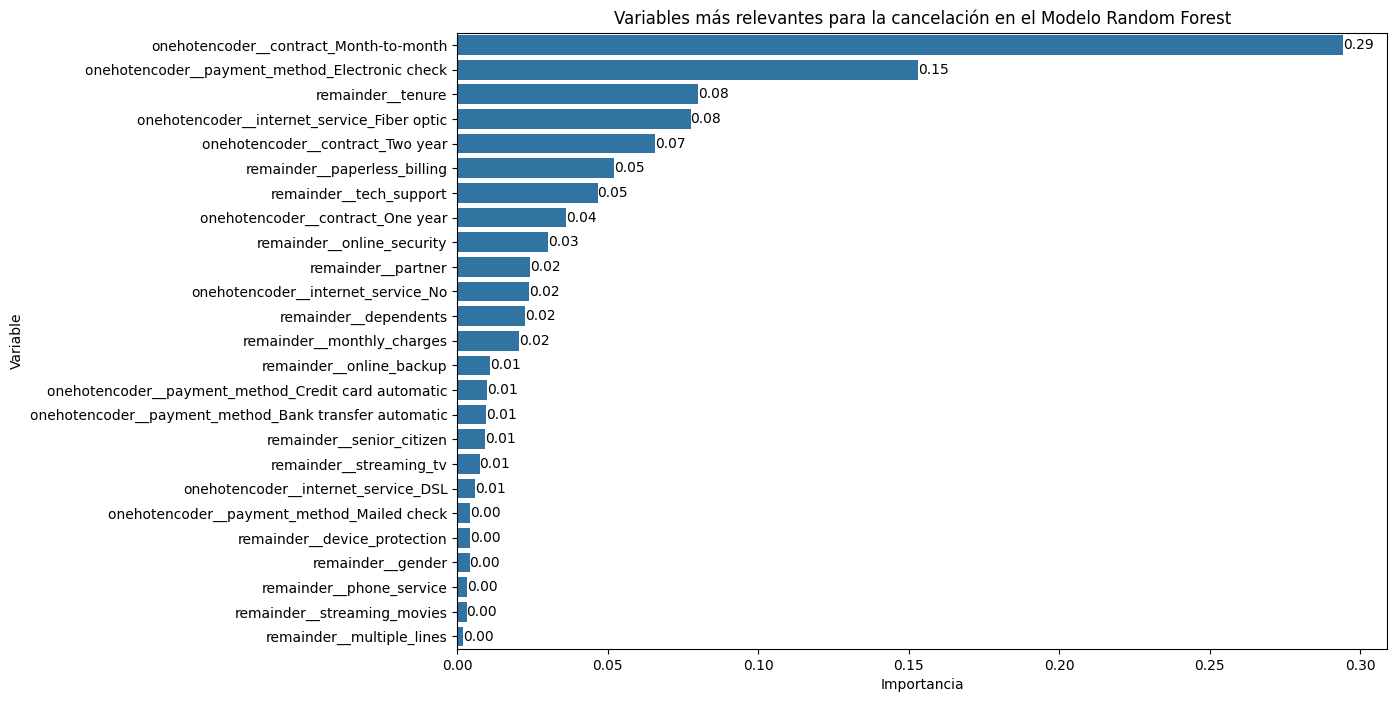

In [101]:
importancias = modelo_rf.feature_importances_
variables = X_train.columns

importancia_df = pd.DataFrame({'Variable': variables, 'Importancia': importancias})
importancia_df = importancia_df.sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(12, 8))
ax = sns.barplot(x='Importancia', y='Variable', data=importancia_df, orient='h')
plt.title('Variables más relevantes para la cancelación en el Modelo Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Variable')

for i in ax.containers:
    ax.bar_label(i, fmt='%.2f')

plt.show()

In [102]:
principales_explicativas = importancia_df.sort_values(by='Importancia', ascending=False).head(10)
suma_importancias = principales_explicativas['Importancia'].sum()
print(f'La suma de las 10 variables más importantes es de: {(suma_importancias*100):.2f}%')

La suma de las 10 variables más importantes es de: 85.97%


In [103]:
print(datos.groupby('contract')['Churn'].mean())

contract
Month-to-month    0.427097
One year          0.112772
Two year          0.028487
Name: Churn, dtype: float64


In [104]:
print(datos.groupby('payment_method')['Churn'].mean())

payment_method
Bank transfer automatic    0.167315
Credit card automatic      0.152531
Electronic check           0.452854
Mailed check               0.192020
Name: Churn, dtype: float64


In [105]:
print(datos.groupby('internet_service')['Churn'].mean())

internet_service
DSL            0.189983
Fiber optic    0.418928
No             0.074342
Name: Churn, dtype: float64


###**Informe de Modelado Predictivo de Churn – Telecom X**

**Resumen**  

Se desarrollaron 3 propuestas de modelado, eligiendo finalmente el modelo Random Forest que alcanza un 88% de acierto en identificar clientes que cancelarán (recall) y una precisión global del 82%. Las variables determinantes son: tipo de contrato, antigüedad, servicio de internet y método de pago.

**Preparación de datos**  

Se utilizaron 7.032 registros limpios.

Se balancearon las clases con SMOTE (50/50), se normalizaron las variables numéricas (`tenure`, `monthly_charges`) con MinMaxScaler y se eliminó `total_charges` por alta correlación con `tenure`.

Las variables categóricas se codificaron con one‑hot encoding.


**Análisis Exploratorio Complementario**

Se confirmó que:



*   Los clientes que cancelan tienen una mediana de antigüedad mucho menor (10 meses) que los que permanecen (38 meses).
*   Los cargos totales son más bajos en el grupo de cancelados (mediana 704 vs 1684), lo que refleja su menor permanencia.

*   Existe una relación lineal fuerte entre `tenure` y `total_charges`, y entre `monthly_charges` y `total_charges`.





**Modelos evaluados**

| Modelo        | Accuracy | Precisión | Recall | F1‑score | Observaciones |
|---------------|----------|-----------|--------|----------|---------------|
| Dummy (base)  | 0.50     | —         | 0.00   | 0.00     | Clasificador trivial. |
| Random Forest | **0.83** | **0.79**  | **0.90**| **0.84** | Mejor equilibrio, generaliza bien. |
| KNN           | 0.77     | 0.72      | 0.89   | 0.80     | Recall similar, menor precisión. |

Se priorizó **recall** (minimizar falsos negativos) por el alto costo de no detectar a un cliente que se va.

**Variables más influyentes**

Las 5 variables más influyentes explican el 86% de la capacidad predictiva:

1. Contrato mensual (23%) – 42.7% de churn.
2. Antigüedad (19%) – mediana de 10 meses en cancelados.
3. Fibra óptica (13%) – 41.9% de churn.
4. Cheque electrónico (8%) – 45.3% de churn.
5. Cargos mensuales (6%) – mayores en cancelados.



**Recomendaciones para el negocio**

1. **Contratos mensuales**: ofrecer descuentos del 10% al migrar a plan anual.
2. **Métodos de pago**: incentivar con $5 de descuento mensual el cambio de cheque electrónico a débito automático.
3. **Clientes nuevos**: implementar llamadas de bienvenida y ofertas de renovación al cumplir 11 meses.
4. **Fibra óptica**: revisar precios y calidad percibida; comunicar beneficios.
5. **Alertas tempranas**: integrar el modelo en un sistema que active ofertas personalizadas para clientes con alta probabilidad de cancelación (churn).